# Markov-switching models — `qufin.timeseries.MarkovSwitchingAR`

The discrete HMM tutorial binned returns into symbols. The **Markov-switching
autoregressive (MS-AR)** model is its *continuous* cousin: it models the returns
**directly**, giving every latent regime its own mean, AR dynamics, **and
volatility**:

$$ y_t = \mu_{S_t} + \sum_{i=1}^p \phi_{S_t,i}(y_{t-i}-\mu_{S_t}) + \sigma_{S_t}\,\varepsilon_t, \qquad S_t \sim \text{Markov}(P) $$

This is exactly the structure of financial regimes: a **calm/bull** state
(small positive drift, low $\sigma$) and a **crisis/bear** state (negative
drift, high $\sigma$). Estimation is by EM (Hamilton 1989 filter + Kim 1994
smoother). Two probability streams matter:

* **Filtered** $\xi_{t\mid t}$ — uses data *up to now*. Causal → tradeable.
* **Smoothed** $\xi_{t\mid T}$ — uses *all* data. Sharper, for hindsight analysis.

**Roadmap**

1. *Provably recovers the truth* — simulate a 2-regime process, refit, compare
2. Filtered vs smoothed probabilities — real-time vs hindsight
3. Real regimes in SPY — quantified bull/bear states
4. Hand-off — the `RegimeSwitchingStrategy` (regime-conditional Kelly)


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qufin.timeseries import MarkovSwitchingAR
from qufin.strategies import RegimeSwitchingStrategy, RegimeSwitchingParams

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
ANNUAL = np.sqrt(252.0)


## 1. Proof it works — recover a 2-regime process

We simulate daily-style returns from a known 2-regime model: a **bull** state
(slightly positive mean, low vol) and a **bear** state (negative mean, ~2.5×
vol), with sticky transitions. Then `MarkovSwitchingAR(p=0, k_regimes=2).fit`
recovers $\mu_k,\sigma_k,P$ from the returns alone (labels up to a permutation,
which we fix by sorting on the mean).


In [2]:
rng = np.random.default_rng(7)
A_true = np.array([[0.985, 0.015],   # 0=bull (very persistent)
                   [0.040, 0.960]])  # 1=bear
mu_true = np.array([0.0006, -0.0010])
sig_true = np.array([0.007, 0.018])

n = 5000
states = np.empty(n, dtype=int); states[0] = 0
for t in range(1, n):
    states[t] = rng.choice(2, p=A_true[states[t-1]])
y = mu_true[states] + sig_true[states] * rng.standard_normal(n)

res = MarkovSwitchingAR(p=0, k_regimes=2).fit(y, max_iter=200, seed=0)
order = np.argsort(res.mu)[::-1]                 # sort regimes bull-first
print('               bull(0)     bear(1)')
print(f'mu    true:  {mu_true[0]:+.5f}   {mu_true[1]:+.5f}')
print(f'mu    est :  {res.mu[order[0]]:+.5f}   {res.mu[order[1]]:+.5f}')
print(f'sigma true:  {sig_true[0]:.5f}    {sig_true[1]:.5f}')
print(f'sigma est :  {np.sqrt(res.sigma2[order[0]]):.5f}    {np.sqrt(res.sigma2[order[1]]):.5f}')
P_est = res.transition[np.ix_(order, order)]
print(f'\ntrue P =\n{A_true}\nest  P =\n{np.round(P_est, 3)}')
print(f'\nlog-lik={res.log_lik:.1f}  converged={res.converged} in {res.n_iter} iters')


               bull(0)     bear(1)
mu    true:  +0.00060   -0.00100
mu    est :  +0.00057   -0.00121
sigma true:  0.00700    0.01800
sigma est :  0.00695    0.01802

true P =
[[0.985 0.015]
 [0.04  0.96 ]]
est  P =
[[0.986 0.014]
 [0.041 0.959]]

log-lik=16289.3  converged=True in 15 iters


## 2. Filtered vs smoothed probabilities

The smoothed probability $\xi_{t\mid T}$ peeks at the future, so it switches
crisply at the true regime boundaries — great for *labelling history*. The
filtered probability $\xi_{t\mid t}$ only knows the past, so it lags slightly at
turning points — but it's the one you can actually act on **live**. Both track
the latent truth well.


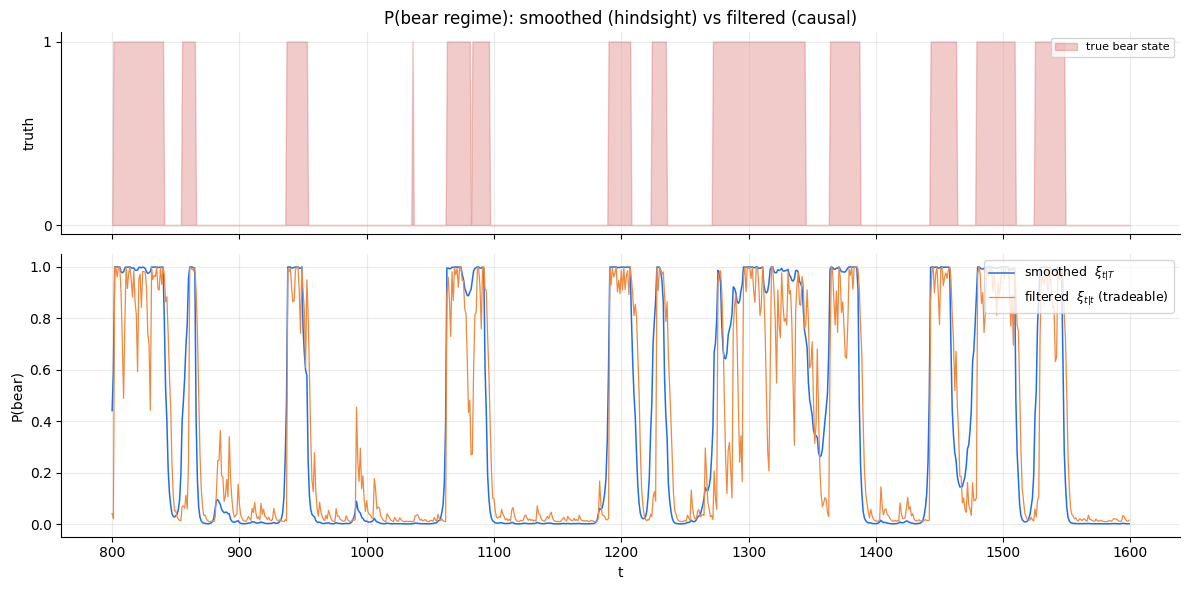

smoothed-state classification accuracy vs truth = 96.0%


In [3]:
bear = order[1]                                   # index of the bear regime
seg = slice(800, 1600)
fig, (axs, axp) = plt.subplots(2, 1, sharex=True, height_ratios=[1, 1.4], figsize=(12, 6))
axs.fill_between(np.arange(n)[seg], (states == 1)[seg], color='#c4302b', alpha=0.25,
                 label='true bear state')
axs.set_yticks([0, 1]); axs.set_ylabel('truth'); axs.legend(loc='upper right', fontsize=8)
axs.set_title('P(bear regime): smoothed (hindsight) vs filtered (causal)')
axp.plot(np.arange(n)[seg], res.smoothed_probs[seg, bear], color='#1f6feb', lw=1.1,
         label='smoothed  $\\xi_{t|T}$')
axp.plot(np.arange(n)[seg], res.filtered_probs[seg, bear], color='#f0883e', lw=0.9,
         label='filtered  $\\xi_{t|t}$ (tradeable)')
axp.set_ylabel('P(bear)'); axp.set_xlabel('t'); axp.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

acc = np.mean((res.smoothed_probs[:, bear] > 0.5) == (states == 1))
print(f'smoothed-state classification accuracy vs truth = {acc:.1%}')


## 3. Real regimes in SPY

Fit the MS-AR to **real** SPY log-returns. Unlike the discrete HMM, we now read
off each regime's **annualised mean and volatility** directly. The model
separates a high-Sharpe calm regime from a negative-drift, high-vol crisis
regime — and the smoothed crisis probability lines up with 2008, 2020 and 2022.


In [4]:
def load_spy(start='2005-01-01', end='2024-12-31'):
    try:
        import yfinance as yf
        s = yf.download('SPY', start=start, end=end, auto_adjust=True, progress=False)
        s = s['Close'].dropna().to_numpy(dtype='float64').ravel()
        if len(s) > 1000:
            return s
    except Exception as exc:
        print(f'yfinance unavailable ({exc!r}); using synthetic regime-switching SPY')
    r = np.random.default_rng(2); m = 5000
    st = np.empty(m, dtype=int); st[0] = 0
    A = np.array([[0.99, 0.01], [0.05, 0.95]])
    for t in range(1, m):
        st[t] = r.choice(2, p=A[st[t-1]])
    rr = np.where(st == 0, r.normal(0.0006, 0.007, m), r.normal(-0.001, 0.02, m))
    return 100 * np.exp(np.cumsum(rr))

spy = load_spy()
ret = np.diff(np.log(spy))
msar = MarkovSwitchingAR(p=0, k_regimes=2).fit(ret, max_iter=200, seed=1)
bear = int(np.argmin(msar.mu))                   # crisis = lower mean
calm = 1 - bear
for k, tag in [(calm, 'calm/bull'), (bear, 'crisis/bear')]:
    dur = 1.0 / (1.0 - msar.transition[k, k])
    print(f'regime {k} [{tag:<11}]: mean={msar.mu[k]*252*100:+6.1f}%/yr  '
          f'vol={np.sqrt(msar.sigma2[k])*ANNUAL*100:5.1f}%/yr  '
          f'avg duration={dur:5.0f} d')
print(f'\nlog-lik={msar.log_lik:.0f}  converged={msar.converged}')


regime 1 [calm/bull  ]: mean= +25.1%/yr  vol= 10.5%/yr  avg duration=   63 d
regime 0 [crisis/bear]: mean= -31.4%/yr  vol= 32.2%/yr  avg duration=   23 d

log-lik=16314  converged=True


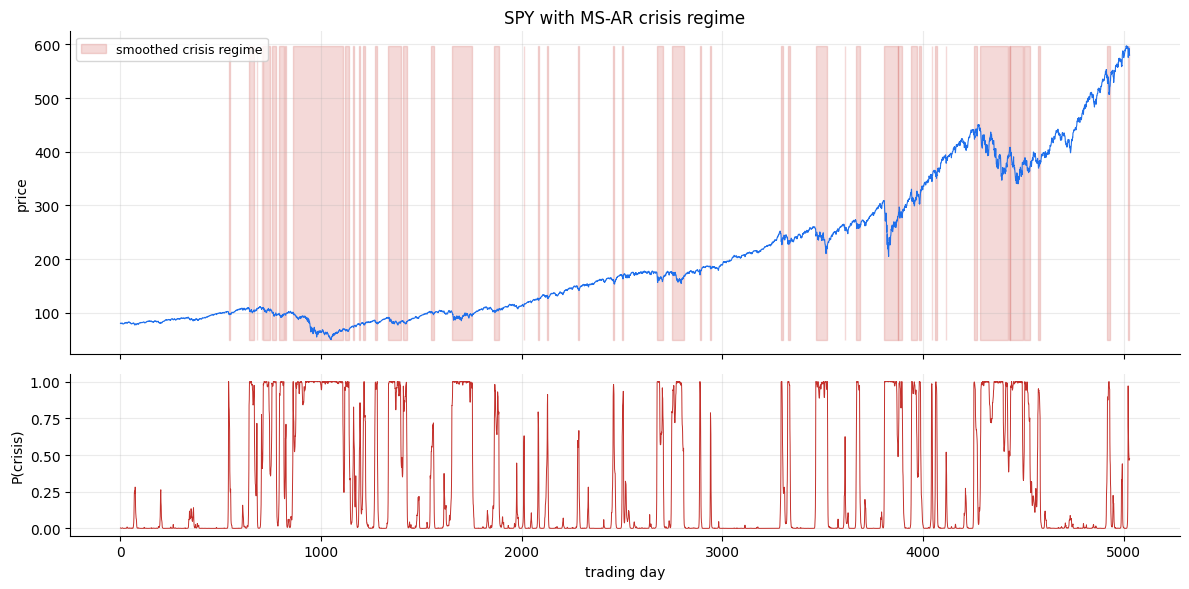

In [5]:
p_bear = msar.smoothed_probs[:, bear]            # length T_eff = len(ret)
fig, (axp, axr) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(12, 6))
axp.plot(spy[1:], color='#1f6feb', lw=0.8)
axp.fill_between(np.arange(len(ret)), spy.min(), spy.max(), where=p_bear > 0.5,
                 color='#c4302b', alpha=0.18, label='smoothed crisis regime')
axp.set_ylabel('price'); axp.set_title('SPY with MS-AR crisis regime'); axp.legend(loc='upper left', fontsize=9)
axr.plot(p_bear, color='#c4302b', lw=0.7); axr.set_ylabel('P(crisis)'); axr.set_xlabel('trading day')
plt.tight_layout(); plt.show()


## 4. Hand-off — the `RegimeSwitchingStrategy`

The strategy refits the MS-AR on a rolling window, runs the **causal** Hamilton
filter between refits, and sets a **regime-conditional Kelly** position:

$$ pos_t = \text{clip}\!\left(\frac{\bar e_t}{\bar\sigma_t^2}\cdot\text{risk\_scale},\;\pm\text{cap}\right), \quad \bar e_t=\sum_k \xi_{t\mid t,k}\,\mu_k $$

It naturally **de-levers or flips short** when the filter assigns weight to the
negative-drift, high-vol regime — risk management that emerges from the model
rather than a hand-set rule. The catch is **turning-point lag**: the causal
filter only switches *after* a regime change is underway, so the strategy can
get whipsawed at tops and bottoms. Keep the leverage modest.


Regime-Switching Summary
  Sharpe (ann.)  : 0.2512
  Total return   : 93.53%
  Max drawdown   : -49.67%
  Avg |position| : 0.899
  Regime durations: R0=1825, R1=2787


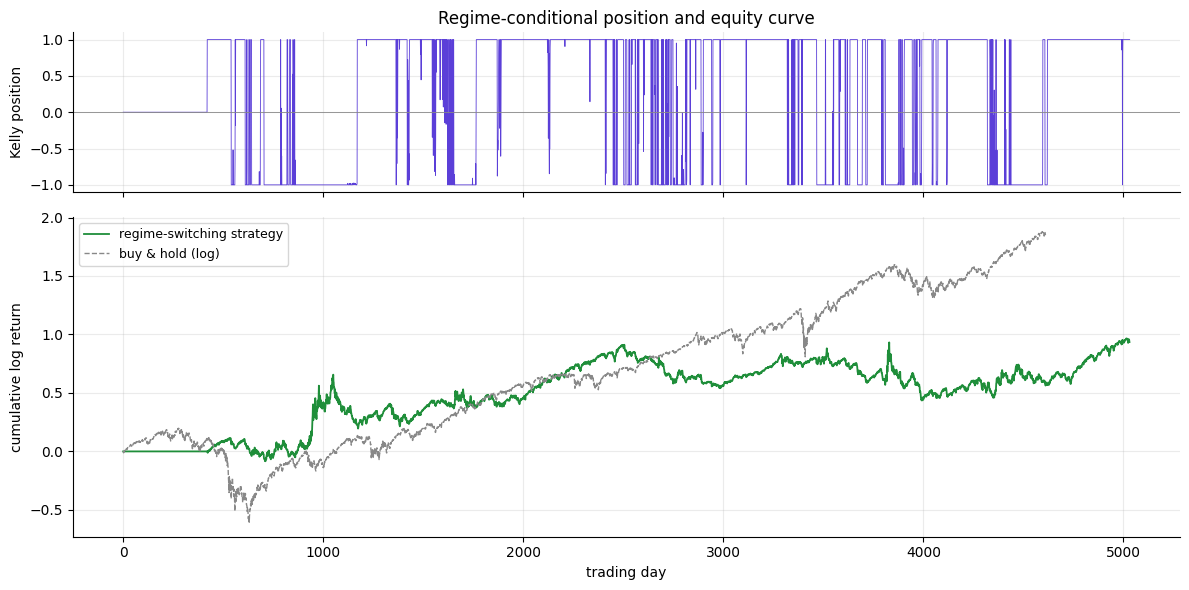

In [6]:
strat = RegimeSwitchingStrategy(RegimeSwitchingParams(
    p=0, k_regimes=2, fit_window=400, refit_every=50, warmup=420,
    risk_scale=1.0, leverage_cap=1.0))
out = strat.run(spy)
print(out.summary())

buyhold = np.cumsum(ret[strat.params.warmup:])
fig, (axpos, axe) = plt.subplots(2, 1, sharex=True, height_ratios=[1, 2], figsize=(12, 6))
axpos.plot(out.position, color='#5b3fd8', lw=0.6); axpos.axhline(0, color='#888', lw=0.6)
axpos.set_ylabel('Kelly position'); axpos.set_title('Regime-conditional position and equity curve')
axe.plot(np.nancumsum(out.log_returns), color='#1f8e3a', lw=1.3, label='regime-switching strategy')
axe.plot(buyhold, color='#888', lw=1.0, ls='--', label='buy & hold (log)')
axe.set_ylabel('cumulative log return'); axe.set_xlabel('trading day'); axe.legend(fontsize=9)
plt.tight_layout(); plt.show()


## What next?

* **Add a crash state.** `k_regimes=3` separates "calm", "correction" and
  "crash" — useful for tail-risk overlays. Compare 2 vs 3 regimes by BIC.
* **AR dynamics.** `p > 0` lets each regime have its own autocorrelation —
  e.g. a trending bull and a choppy bear.
* **Regime-gate other signals.** Use the filtered crisis probability to scale a
  momentum or pairs book down in turbulent states, rather than trading the
  regime directly.
* **Compare to GARCH.** MS-AR and GARCH both model time-varying volatility; the
  MS-AR adds a *discrete* regime label and a regime-dependent **mean**. See the
  GARCH volatility tutorial.
